In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,MAX_NOISE,RXPACC
0,0,3.90,745,18712,10250,11576,11855,967,611
1,0,0.66,749,11239,6313,4712,18968,1133,447
2,1,7.86,746,4355,5240,3478,14699,894,723
3,1,3.48,750,8502,8416,5890,8748,1127,1024
4,0,1.19,746,17845,18095,12058,11380,1744,276


In [8]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

Neural Network Test Accuracy: 0.7901

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.98      0.82      6278
           1       0.97      0.60      0.74      6322

    accuracy                           0.79     12600
   macro avg       0.84      0.79      0.78     12600
weighted avg       0.84      0.79      0.78     12600

Confusion Matrix:
[[6163  115]
 [2530 3792]]


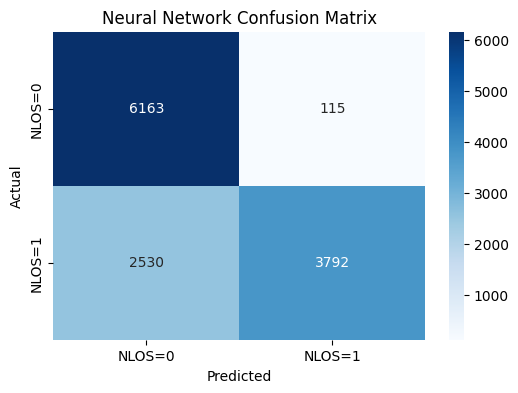

In [10]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create and train the neural network classifier
# Here we use one hidden layer with 100 neurons. You can adjust hidden_layer_sizes, max_iter, etc.
nn_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=111)
nn_model.fit(X_train, y_train)

# Predict on the test set
y_pred_nn = nn_model.predict(X_test)

# Evaluate the performance
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print("Neural Network Test Accuracy: {:.4f}".format(accuracy_nn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

# Compute the confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
print("Confusion Matrix:")
print(cm_nn)

# Visualize the confusion matrix with custom labels
plt.figure(figsize=(6,4))
sns.heatmap(cm_nn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")
plt.show()


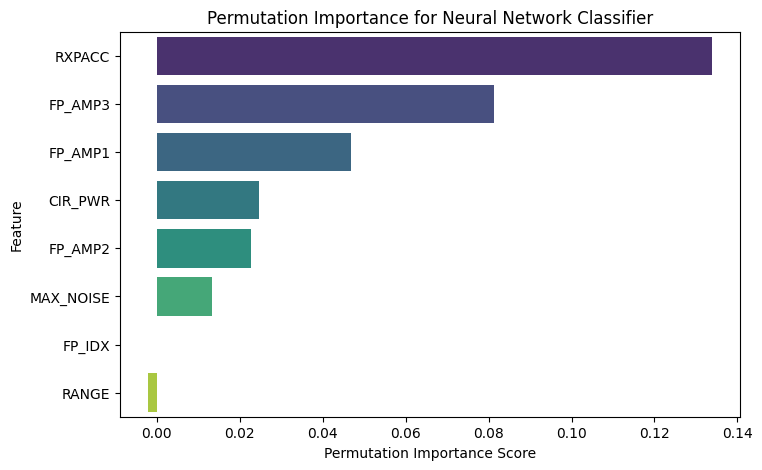

In [11]:
# ==============================
# Permutation Importance for Neural Network Classifier
# ==============================

from sklearn.inspection import permutation_importance

# Compute permutation importance on the test set using 'accuracy' as the scoring metric
r = permutation_importance(nn_model, X_test, y_test, n_repeats=10, random_state=111, scoring='accuracy')

# Convert the mean importance values into a Pandas Series with feature names as the index
perm_importances = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=perm_importances.values, 
                 y=perm_importances.index, 
                 hue=perm_importances.index, 
                 palette="viridis", 
                 dodge=False)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlabel("Permutation Importance Score")
plt.ylabel("Feature")
plt.title("Permutation Importance for Neural Network Classifier")
plt.show()